In [2]:
import os
import sys
from dotenv import load_dotenv
from pathlib import Path
import datetime as dt

import pandas as pd
import yfinance as yf
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [5]:
# environment variables
env_path = Path("/home/jovyan/.env")
load_dotenv(env_path)

# mounted data directory in container
data_path = Path("/home/jovyan/data/data-main")

print("cwd:", Path.cwd())
print("data_path:", data_path)
print("exists:", data_path.exists())

cwd: /home/jovyan
data_path: /home/jovyan/data/data-main
exists: True


In [12]:
# finance/data/data-main/3_single_factor_data.csv
data = pd.read_csv(data_path / "3_single_factor_data.csv", parse_dates=True).sort_index()
df = data.set_index("Date")
company_list = ["Tesla", "Nasdaq", "GM", "DowJones"]
df.columns = company_list
df.describe()


,Tesla,Nasdaq,GM,DowJones
count,2768.000000,2768.000000,2768.000000,2768.000000
mean,0.537736,0.144483,0.123480,0.103212
std,8.950417,3.183218,5.363425,2.674306
min,-52.657057,-30.803124,-43.307281,-32.316367
25%,-3.739827,-1.152923,-2.515808,-0.911390
50%,0.316036,0.228293,0.078314,0.137206
75%,4.743197,1.737332,2.663932,1.310524
max,60.988135,23.364743,49.859026,28.412596


In [21]:
lr1 = LinearRegression()
X = df[["Nasdaq"]].values
Y = df["Tesla"].values
X1 = np.delete(X, 0, 0)
Y1 = np.delete(Y, 0, 0)
lr1.fit(X1, Y1)
print("β = ", lr1.coef_[0])
print('intercept = %.4f' % lr1.intercept_)
print('R_squared = %.4f' % lr1.score(X1, Y1))

β =  1.437527460380613
intercept = 0.3313
R_squared = 0.2614


In [22]:
lr2 = LinearRegression()
X = df[["Nasdaq"]].values
Y = df["GM"].values
X2 = np.delete(X, 0, 0)
Y2 = np.delete(Y, 0, 0)
lr2.fit(X2, Y2)
print("β = ", lr2.coef_[0])
print('intercept = %.4f' % lr2.intercept_)
print('R_squared = %.4f' % lr2.score(X2, Y2))

β =  0.9428378250062681
intercept = -0.0132
R_squared = 0.3131


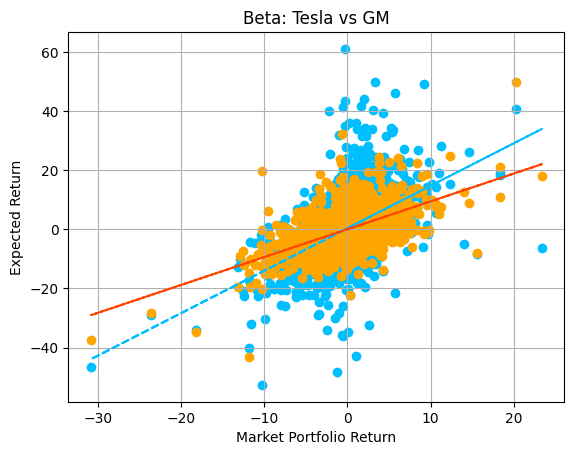

In [23]:
plt.scatter(X1, Y1, color='deepskyblue')

plt.plot(X1, lr1.predict(X1), linestyle='dashed', color='deepskyblue')

plt.scatter(X2, Y2, color='orange')

plt.plot(X2, lr2.predict(X2), linestyle='dashed', color='orangered')

plt.title("Beta: Tesla vs GM")
plt.xlabel("Market Portfolio Return")
plt.ylabel("Expected Return")
plt.grid()
plt.show()



### 3.5 証券市場線（SML）の導出

In [24]:
import matplotlib.pyplot as plt

In [25]:
def SML(rf, rm, label):
    Beta = [x / 10 for x in range(20)]
    ExpectedReturn = [rf + (rm - rf) * x for x in Beta]
    # 縦軸Epを算出
    plt.plot(Beta, ExpectedReturn, label=label)
    plt.xlabel("Beta")
    plt.ylabel("Expected Return")
    plt.title("Security Market Line")
    plt.plot(1, rm, "ro")

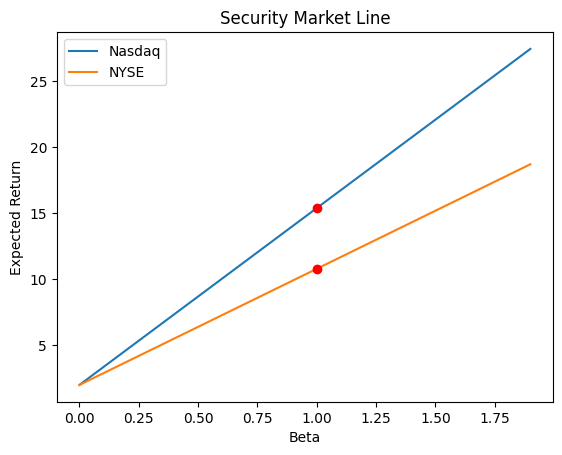

In [26]:
SML(2.0, 15.4, "Nasdaq")
SML(2.0, 10.8, "NYSE")
plt.legend()
plt.show()